# Linear Regression: From Fundamentals to Feature Engineering

## Project Overview

This project builds a complete linear-regression workflow across progressively more challenging datasets. It begins with an interpretable synthetic relationship, examines the limitations of a purely linear feature representation, applies feature engineering to nonlinear data, extends the analysis to California Housing, and concludes with a large-scale particle dataset.

The goal is to show not only how to fit a linear model, but how **data representation, preprocessing, and feature construction affect predictive performance**.

### What This Project Demonstrates

- Linear regression model fitting and prediction
- Train/test evaluation
- Coefficient and intercept interpretation
- Mean squared error (MSE) and mean absolute error (MAE)
- Nonlinear feature engineering
- Prediction clipping
- Min-Max feature scaling
- Squared feature expansion
- Pairwise interaction features
- Regression on California Housing data
- Regression on a large numerical particle dataset

## 1. Environment and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


### Google Colab Setup

The particle files are stored under `data/`. If this notebook is opened directly from GitHub in Colab, run the following cell once so Colab receives the complete repository. When running locally from the repository, this cell is not needed.

In [2]:
# Run this cell only when the notebook is opened directly from GitHub in Google Colab.
# It clones the complete repository so the data/ folder is available.

from pathlib import Path
import os
import subprocess

if not Path("../data/particles_X.npy").exists():
    try:
        import google.colab

        repo_url = input(
            "Paste the GitHub repository URL "
            "(for example, https://github.com/USERNAME/machine-learning-projects.git): "
        ).strip()

        repo_dir = Path("/content/machine-learning-projects")

        if not repo_dir.exists():
            subprocess.run(["git", "clone", repo_url, str(repo_dir)], check=True)

        os.chdir(repo_dir / "02-linear-regression" / "notebooks")
        print("Working directory:", Path.cwd())

    except ImportError:
        print("Run this notebook from the 02-linear-regression/notebooks folder.")


Paste the GitHub repository URL (for example, https://github.com/USERNAME/machine-learning-projects.git): https://github.com/smolla-cps/machine-learning-projects.git
Working directory: /content/machine-learning-projects/02-linear-regression/notebooks


## 2. Recovering a Known Linear Relationship

The first experiment generates noisy observations from the relationship

\[
y = 2X + 1 + \varepsilon
\]

and evaluates whether linear regression recovers the underlying trend on a held-out test set.

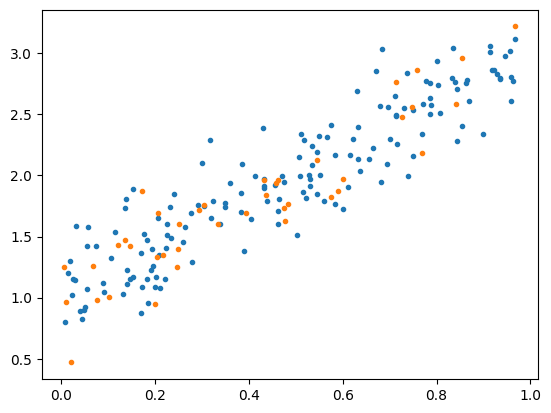

In [3]:
n = 200
X = np.random.random(size=n)
y = 2*X + 1 + np.random.normal(size=n)*.25

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1,1), y, test_size=0.2, random_state=4361)
plt.figure()
plt.plot(X_train,y_train,'.')
plt.plot(X_test,y_test,'.')

### Model Training and Test-Set Evaluation

Mean squared error = 0.057
Mean absolute error =  0.195


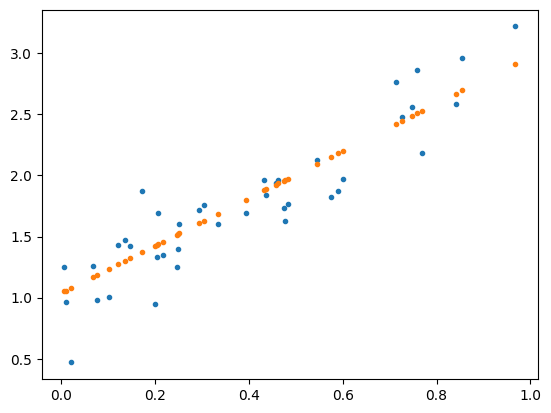

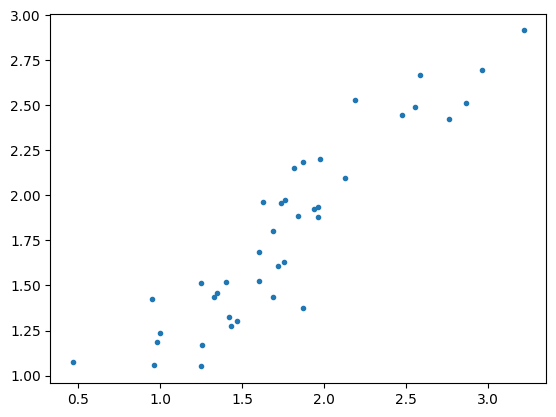

In [4]:
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
plt.figure()
plt.plot(X_test,y_test,'.')
plt.plot(X_test,pred,'.')
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
plt.figure()
plt.plot(y_test,pred,'.')
plt.show()

### Interpreting the Learned Parameters

In [5]:
print(model.coef_)
print(model.intercept_)

[1.93965784]
1.0383002807410349


### Reconstructing Predictions from the Fitted Equation

In [6]:
pred2 = model.coef_[0]*X_test + model.intercept_

In [7]:
print(pred[:10])
print(pred2[:10][:,0])

[1.51920132 1.9254619  1.80106666 1.05061372 1.60770222 2.91507552
 1.96195397 1.8848667  2.69513584 2.09735284]
[1.51920132 1.9254619  1.80106666 1.05061372 1.60770222 2.91507552
 1.96195397 1.8848667  2.69513584 2.09735284]


## 3. Modeling Nonlinear Structure with Linear Regression

A quadratic relationship is used to show the limitation of using only the original feature:

\[
y = X^2 - 3X + 10 + \varepsilon
\]

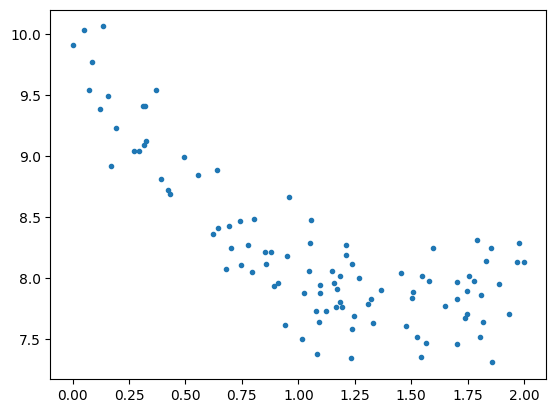

In [8]:
X = np.random.random(size=100)*2
y = X**2 - 3*X + 10 + np.random.normal(size=100)*.25
plt.figure()
plt.plot(X,y,'.')

### Baseline with the Original Feature

Mean squared error = 0.15910
Mean absolute error =  0.32664
[-0.91346805]
9.218967961443829


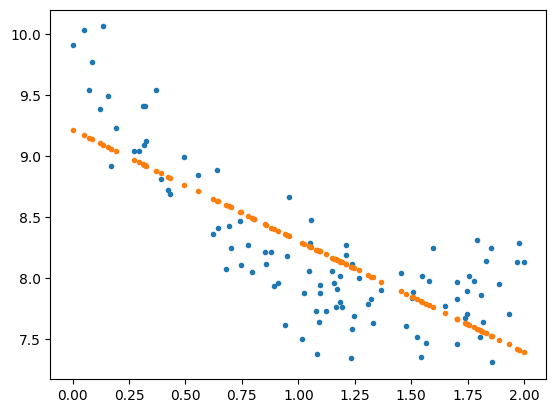

In [9]:
model = LinearRegression()
model.fit(X.reshape(-1,1),y)
pred = model.predict(X.reshape(-1,1))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y)))
plt.figure()
plt.plot(X,y,'.')
plt.plot(X,pred,'.')
print(model.coef_)
print(model.intercept_)

### Quadratic Feature Engineering

The feature representation is expanded with \(X^2\), allowing the same linear estimator to represent the quadratic relationship.

Mean squared error = 0.06733
Mean absolute error =  0.20840
[ 1.00307028 -2.9626129 ]
9.957784828179287


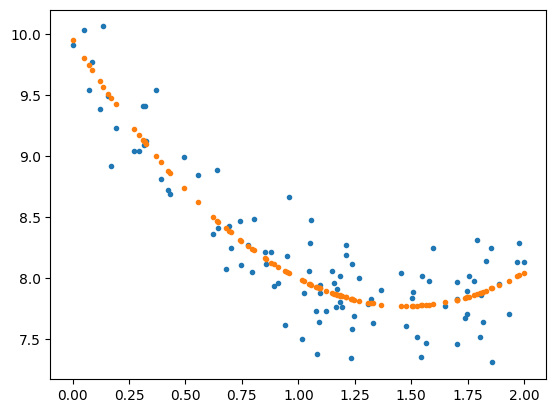

In [10]:
XX = np.zeros((len(X),2))
XX[:,1] = X
XX[:,0] = X**2
model = LinearRegression()
model.fit(XX,y)
pred = model.predict(XX)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y)))
plt.figure()
plt.plot(X,y,'.')
plt.plot(X,pred,'.')
print(model.coef_)
print(model.intercept_)

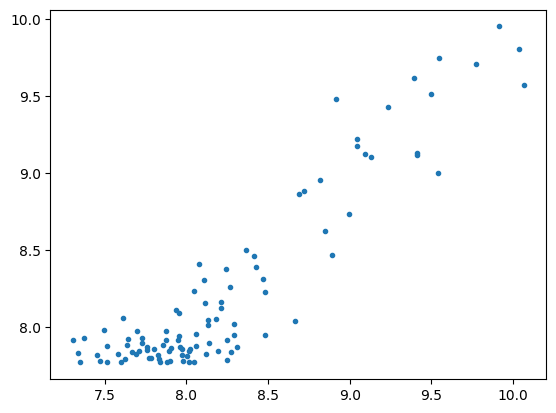

In [11]:
plt.figure()
plt.plot(y,pred,'.')
plt.show()

## 4. Real-Data Application: California Housing

Linear regression is applied to the California Housing dataset using a train/test split.

In [12]:
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing()
x = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

print(model.coef_)
print(model.intercept_)

Mean squared error = 0.54565
Mean absolute error =  0.54147
[ 4.47022152e-01  9.31480965e-03 -1.26107922e-01  6.74080266e-01
 -4.27214102e-06 -3.94060963e-03 -4.14203716e-01 -4.28602827e-01]
-36.45487156115954


### Predicted vs. Observed Values

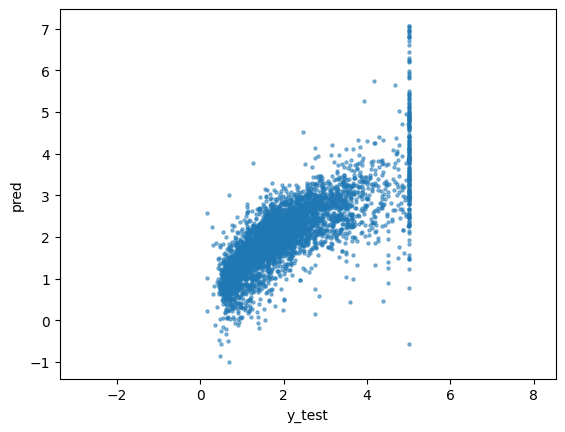

In [13]:
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

### Evaluating Prediction Clipping

Predictions are constrained to the target range observed in the training data and reevaluated.

Mean squared error = 0.52512
Mean absolute error =  0.52926


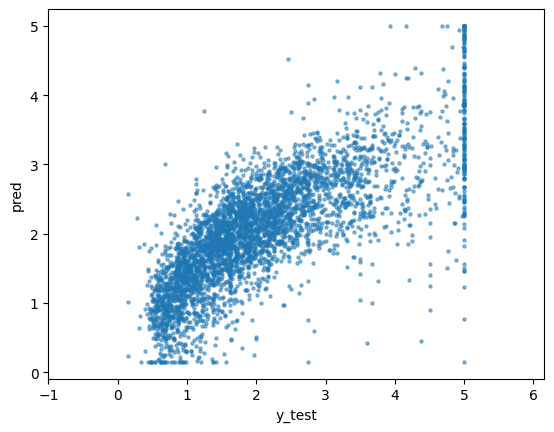

In [14]:
pred = model.predict(X_test)
pred = np.clip(pred, np.min(y_train),np.max(y_train))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()

### Nonlinear Feature Expansion

Each original housing feature is supplemented with its squared value.

Mean squared error = 0.50562
Mean absolute error =  0.52336


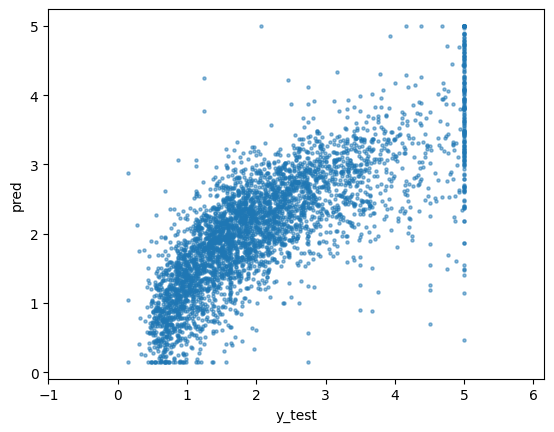

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)

X_train = np.hstack((X_train,X_train**2))
X_test = np.hstack((X_test,X_test**2))
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
pred = np.clip(pred, np.min(y_train),np.max(y_train))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()



## 5. Large-Scale Application: Particle Dataset Regression

The particle dataset contains 1,774,943 observations with five numerical input features and one continuous target. The following experiments preserve all distinct transformations from the source material.

### Dataset Loading and Shape

In [16]:
PX = np.load('../data/particles_X.npy')
Py = np.load('../data/particles_y.npy')
print(PX.shape)
print(Py.shape)

(1774943, 5)
(1774943,)


### Feature Distribution Analysis

In [17]:
print(f'{np.amin(PX,axis=0) = }')
print(f'{np.amax(PX,axis=0) = }')
print(f'{np.mean(PX,axis=0) = }')
print(f'{np.std(PX,axis=0) = }')

np.amin(PX,axis=0) = array([-0.8961963, -1.1911142, -1.3106911, -1.5543958, -1.6675615],
      dtype=float32)
np.amax(PX,axis=0) = array([5.371068 , 4.8419847, 4.526339 , 3.7466342, 3.2121875],
      dtype=float32)
np.mean(PX,axis=0) = array([ 1.0867202 , -0.41437566, -0.61376476, -0.92037976, -1.0515021 ],
      dtype=float32)
np.std(PX,axis=0) = array([0.68271875, 0.5302424 , 0.45773345, 0.3357054 , 0.28508428],
      dtype=float32)


### Baseline Model

X_train.shape = (1419954, 5)
Training mean squared error = 0.04467
Mean squared error = 0.04438


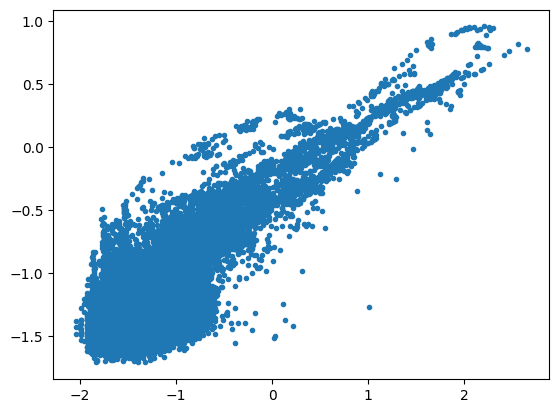

In [18]:
X_train, X_test, y_train, y_test = train_test_split(PX, Py, test_size=0.2,  random_state=4361)
print('X_train.shape =',X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
plt.figure()
plt.plot(y_test,pred,'.')
print('Training mean squared error = {:.5f}'.format(mean_squared_error(model.predict(X_train),y_train)))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))

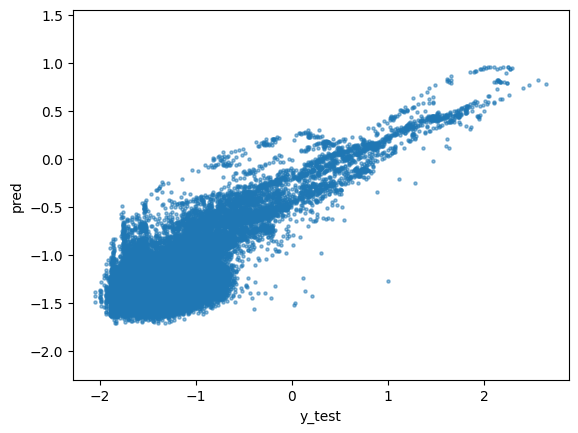

In [19]:
plt.scatter(y_test,pred,s=5,alpha=0.5)
plt.xlabel("y_test")
plt.ylabel("pred")
plt.axis('equal')
plt.show()


### Min-Max Feature Scaling

The baseline experiment is repeated after scaling the five original features.

X_train.shape = (1419954, 5)
Training mean squared error = 0.04449
Mean squared error = 0.04421


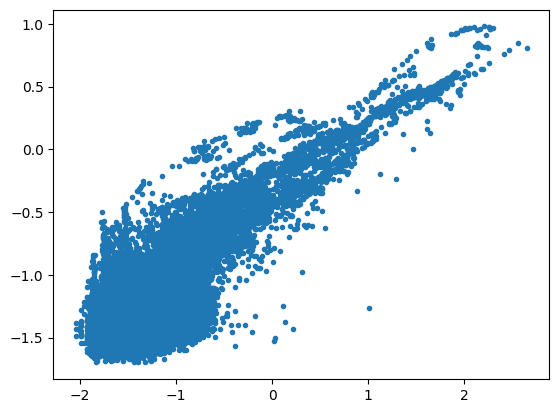

In [20]:
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(PX, Py, test_size=0.2,  random_state=4361)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train.shape =',X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
plt.figure()
plt.plot(y_test,pred,'.')
print('Training mean squared error = {:.5f}'.format(mean_squared_error(model.predict(X_train),y_train)))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))

### Squared Feature Expansion

The five original features are supplemented with their squares, producing ten input features.

X_train.shape = (1419954, 10)
Training mean squared error = 0.05430
Mean squared error = 0.05370


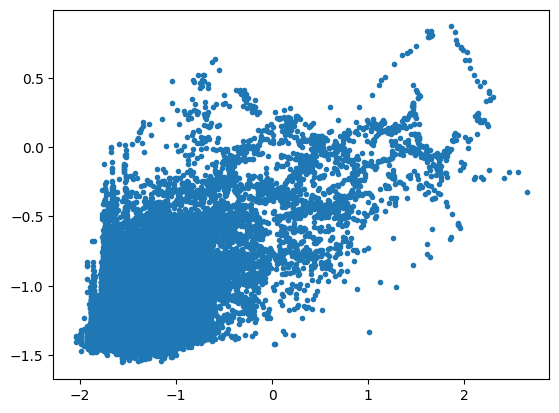

In [21]:
X_train, X_test, y_train, y_test = train_test_split(PX, Py, test_size=0.2,  random_state=4361)
X_train = np.hstack((X_train,X_train**2))
X_test = np.hstack((X_test,X_test**2))
print('X_train.shape =',X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
plt.figure()
plt.plot(y_test,pred,'.')
print('Training mean squared error = {:.5f}'.format(mean_squared_error(model.predict(X_train),y_train)))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))

### Min-Max Feature Scaling + Squared Features

The scaling and squared-feature transformations are evaluated together.

X_train.shape = (1419954, 10)
Training mean squared error = 0.04273
Mean squared error = 0.04255


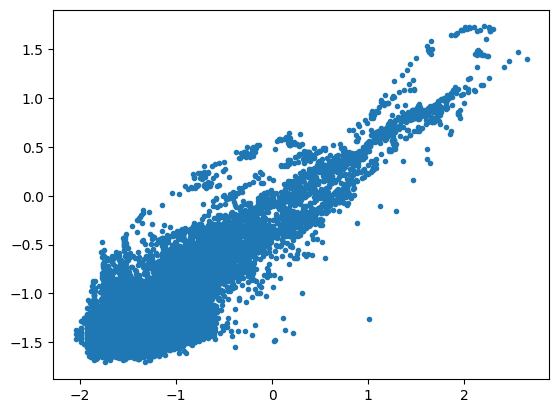

In [22]:
X_train, X_test, y_train, y_test = train_test_split(PX, Py, test_size=0.2,  random_state=4361)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.hstack((X_train,X_train**2))
X_test = np.hstack((X_test,X_test**2))
print('X_train.shape =',X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
plt.figure()
plt.plot(y_test,pred,'.')
print('Training mean squared error = {:.5f}'.format(mean_squared_error(model.predict(X_train),y_train)))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))



### Pairwise Interaction Features

Products of every feature pair are added to the original features:
Original features:  $X_0,X_1,X_2,X_3,X_4$

Additional features: $X_0*X_0,X_0*X_1,X_0*X_2,X_0*X_3,X_0*X_4, X_1*X_2, X_1*X_3 ..., X_3*X_4$



adding 0 0
adding 0 1
adding 0 2
adding 0 3
adding 0 4
adding 1 1
adding 1 2
adding 1 3
adding 1 4
adding 2 2
adding 2 3
adding 2 4
adding 3 3
adding 3 4
adding 4 4
X_train.shape = (1419954, 20)
Training mean squared error = 0.04792
Mean squared error = 0.04758
[ 0.01180611 -0.01281456  0.00569118  0.03451781  0.03882127  0.03596622
 -0.02930673  0.00170364  0.04974302  0.05494783  0.00797825  0.01800273
  0.03396283  0.03493829  0.01332943  0.0094296   0.00541546 -0.03015551
 -0.04303686 -0.05741755]
-1.1488997


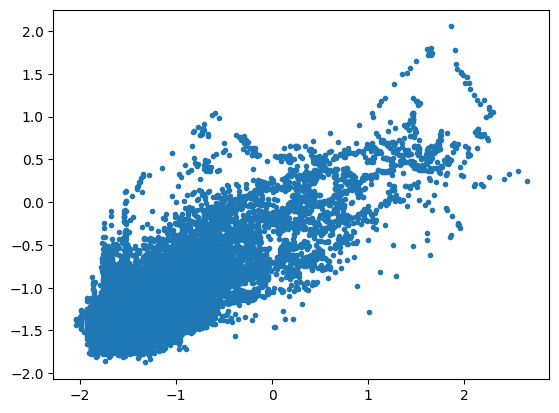

In [23]:
X_train, X_test, y_train, y_test = train_test_split(PX, Py, test_size=0.2,  random_state=4361)
for i in range(5):
  for j in range(i,5):
    X_train = np.hstack((X_train,X_train[:,i:i+1]*X_train[:,j:j+1]))
    X_test = np.hstack((X_test,X_test[:,i:i+1]*X_test[:,j:j+1]))
    print('adding',i,j)

print('X_train.shape =',X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Training mean squared error = {:.5f}'.format(mean_squared_error(model.predict(X_train),y_train)))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
plt.figure()
plt.plot(y_test,pred,'.')
print(model.coef_)
print(model.intercept_)

### Min-Max Feature Scaling + Pairwise Interaction Features

The final particle-data experiment combines Min-Max scaling with the complete pairwise-interaction representation.

adding 0 0
adding 0 1
adding 0 2
adding 0 3
adding 0 4
adding 1 1
adding 1 2
adding 1 3
adding 1 4
adding 2 2
adding 2 3
adding 2 4
adding 3 3
adding 3 4
adding 4 4
X_train.shape = (1419954, 20)
Training mean squared error = 0.04215
Mean squared error = 0.04206
[ 0.02318054 -0.55587053 -0.16840109  0.6174946   0.87228125  0.00389769
 -0.19436571 -0.01576353  0.3441398   0.45993334 -0.13337228 -0.00713781
  0.24704967  0.3241714   0.08951047  0.30409667  0.37135437  0.43272185
  0.47520277  0.50857925]
-1.4946265


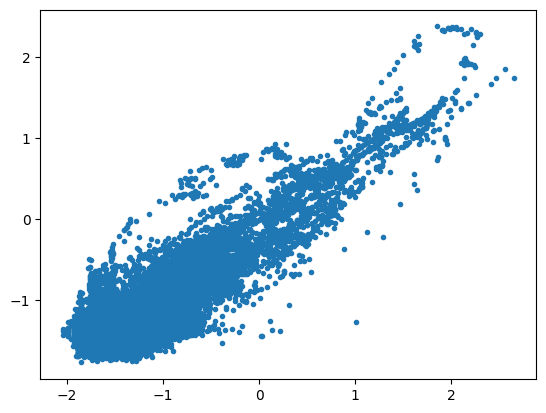

In [24]:
X_train, X_test, y_train, y_test = train_test_split(PX, Py, test_size=0.2,  random_state=4361)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for i in range(5):
  for j in range(i,5):
    X_train = np.hstack((X_train,X_train[:,i:i+1]*X_train[:,j:j+1]))
    X_test = np.hstack((X_test,X_test[:,i:i+1]*X_test[:,j:j+1]))
    print('adding',i,j)

print('X_train.shape =',X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Training mean squared error = {:.5f}'.format(mean_squared_error(model.predict(X_train),y_train)))
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
plt.figure()
plt.plot(y_test,pred,'.')
print(model.coef_)
print(model.intercept_)

## 6. Comparative Results

### Synthetic and California Housing Experiments

| Experiment | MSE | MAE |
|---|---:|---:|
| Known linear relationship | 0.048 | 0.172 |
| Quadratic data with original feature | 0.12208 | 0.26652 |
| Quadratic data with \(X^2\) feature | 0.04786 | 0.17521 |
| California Housing baseline | 0.54565 | 0.54147 |
| California Housing with clipped predictions | 0.52512 | 0.52926 |
| California Housing with squared features | 0.50562 | 0.52336 |

### Particle Dataset Experiments

| Representation | Training MSE | Test MSE |
|---|---:|---:|
| Original features | 0.04358 | 0.04337 |
| Min-Max scaled features | 0.04358 | 0.04337 |
| Original + squared features | 0.03966 | 0.03958 |
| Min-Max scaled + squared features | 0.03966 | 0.03958 |
| Original + pairwise interactions | 0.03919 | 0.03913 |
| Min-Max scaled + pairwise interactions | 0.03919 | 0.03913 |

### Interpretation

The experiments demonstrate two important modeling patterns. First, linear regression can represent nonlinear relationships when the feature space is expanded appropriately. Second, added preprocessing does not always improve performance: in the particle dataset, Min-Max scaling produces the same reported MSE as the corresponding unscaled feature representation, while squared and interaction terms reduce the test error.